HASN'T WORKED - NEEDS SOME MODEL DEBUGGING 

In [1]:
import warnings
warnings.filterwarnings("ignore")
# expandable_segments allows the allocator to create a segment initially and then expand its size later when more memory is needed.
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import tracemalloc
import numpy as np
import os.path as osp
import matplotlib.pyplot as plt

import torch

from src.datasets import DatasetBuilder
from src.models.classifiers import SimpleCNNtorch
from src.utils import seed_everything, get_config, load_model_weights, evaluate_classification_model
from src.cf_methods.coin import CounterfactualCGAN, CounterfactualTrainer, CounterfactualInpaintingCGAN, CounterfactualInpaintingTrainer

2025-06-25 17:22:18.684562: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750864938.701796 2255666 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750864938.707023 2255666 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750864938.720841 2255666 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750864938.720859 2255666 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750864938.720861 2255666 computation_placer.cc:177] computation placer alr

In [2]:
seed_everything()

In [3]:
config_dir = '/data/leuven/365/vsc36567/CF-Robustness-Benchmark/configs' 
config_path = osp.join(config_dir, 'coin_fmnist.yaml') 
config = get_config(config_path) 


ds_builder = DatasetBuilder(config)
ds_builder.setup()
train_loader, val_loader, test_loader = ds_builder.get_dataloaders()

In [4]:
config.n_epochs = 30

baseline_classifier = SimpleCNNtorch(**config.classifier.args,
                                    img_size=config.data.img_size)
load_model_weights(baseline_classifier, weights_path=config.classifier.checkpoints_path, lightning_used=True)
evaluate_classification_model(baseline_classifier, test_loader, config.data.num_classes)
baseline_classifier = baseline_classifier.to(config.accelerator)

Accuracy for the test dataset: 98.800%


In [9]:
baseline_classifier(images.to(config.accelerator))

tensor([[-7.2940e+00, -6.7986e-04],
        [-1.1974e+01, -6.3181e-06],
        [-9.7490e-04, -6.9337e+00],
        [-5.0068e-06, -1.2196e+01],
        [-2.6878e-04, -8.2216e+00]], device='cuda:0')

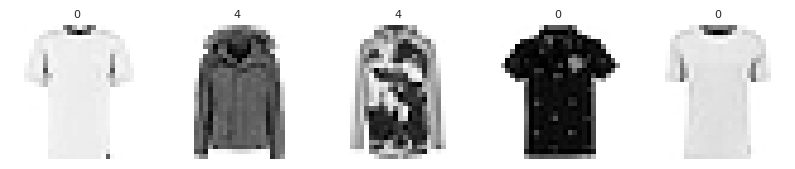

In [5]:
plt.style.use('seaborn-v0_8-darkgrid')

n_samples = 5
class_names = ds_builder.class_encodings
fig, axs = plt.subplots(1, n_samples, figsize=(10, 6))

batch = next(iter(train_loader))
images = batch[0][:n_samples]
labels = batch[1][:n_samples]

for i in range(n_samples):
    axs[i].imshow(images[i, ...].permute(1, 2, 0))
    axs[i].set_title(class_names[labels[i].item()], fontdict={'fontsize': 8})
    axs[i].axis("off")

In [5]:
# continue_path = '/data/leuven/365/vsc36567/CF-Robustness-Benchmark/cf_output/fmnist/coin_cfe-June-25-2025_05+01PM-exp/checkpoints'
cfcgan_inpainting = CounterfactualInpaintingCGAN(baseline_classifier, opt=config, img_size=config.data.img_size)
trainer = CounterfactualInpaintingTrainer(opt=config, model=cfcgan_inpainting) #, continue_path=continue_path)

[2025-06-25 17:22:46|INFO] - ================ Session (Wed Jun 25 17:22:46 2025) ================
[2025-06-25 17:22:46|INFO] - Logging directory: /data/leuven/365/vsc36567/CF-Robustness-Benchmark/cf_output/fmnist/coin_cfe-June-25-2025_05+22PM-exp


Using SNConv in generator: False
Generator in channels [256, 384, 192]
Generator out channels [256, 128, 64]
Using SNConv in generator: False
Using perturbation fuse scheme: skip_add_tanh


In [6]:
trainer.fit([train_loader, val_loader])

RuntimeError: Given groups=1, weight of size [64, 1, 1, 1], expected input[5, 3, 12, 12] to have 1 channels, but got 3 channels instead

# Robustness evaluation

In [14]:
checkpoints_path = '/data/leuven/365/vsc36567/CF-Robustness-Benchmark/cf_output/derma/coin_cfe-June-25-2025_12+01PM-exp/checkpoints/checkpoint_30.pth'
cfcgan_inpainting = CounterfactualInpaintingCGAN(opt=config, img_size=config.data.img_size)
trainer = CounterfactualInpaintingTrainer(opt=config, model=cfcgan_inpainting, continue_path=checkpoints_path)
trainer.restore_state()

Using SNConv in generator: False
Generator in channels [512, 768, 384, 192]
Generator out channels [512, 256, 128, 64]
Using SNConv in generator: False
Using perturbation fuse scheme: skip_add_tanh


[2025-06-25 14:17:48|INFO] - ================ Session (Wed Jun 25 14:17:48 2025) ================
[2025-06-25 14:17:48|INFO] - ================ Session (Wed Jun 25 14:17:48 2025) ================
[2025-06-25 14:17:48|INFO] - ================ Session (Wed Jun 25 14:17:48 2025) ================
[2025-06-25 14:17:48|INFO] - Logging directory: /data/leuven/365/vsc36567/CF-Robustness-Benchmark/cf_output/derma/coin_cfe-June-25-2025_12+01PM-exp
[2025-06-25 14:17:48|INFO] - Logging directory: /data/leuven/365/vsc36567/CF-Robustness-Benchmark/cf_output/derma/coin_cfe-June-25-2025_12+01PM-exp
[2025-06-25 14:17:48|INFO] - Logging directory: /data/leuven/365/vsc36567/CF-Robustness-Benchmark/cf_output/derma/coin_cfe-June-25-2025_12+01PM-exp
[2025-06-25 14:17:48|INFO] - Restored checkpoint /data/leuven/365/vsc36567/CF-Robustness-Benchmark/cf_output/derma/coin_cfe-June-25-2025_12+01PM-exp/checkpoints/checkpoint_30.pth (June 25, 2025)
[2025-06-25 14:17:48|INFO] - Restored checkpoint /data/leuven/365/v

In [15]:
baseline_classifier = trainer.model.classifier_f
evaluate_classification_model(baseline_classifier.to('cpu'), test_loader, num_classes=2)

Accuracy for the test dataset: 86.286%


### Local Instability

In [16]:
from src.utils import extract_factual_instances, filter_valid_factuals
from src.evaluation.local_instability import calculate_ssim, calculate_sparsity
from src.evaluation.local_instability import perturb_sample
from src.utils import plot_perturbed_factuals_and_cf
from functools import reduce

In [17]:
target_class = 0 # benign lesions
factual_class = 1 # abnormal melanoma lesions

device = config.accelerator
# baseline_classifier = trainer.model.classifier_f
# explainer = trainer.model.gen
os.makedirs(config.save_dir, exist_ok=True)

factuals, labels = extract_factual_instances(test_loader, [factual_class])
factuals, labels = filter_valid_factuals(factuals, labels, trainer.model.classifier_f, device)
print('Total number of factuals after filtering: ', factuals.shape[0])

Total number of factuals after filtering:  57


In [18]:
cfes = []
for i in list(range(factuals.shape[0]))[:30]:
    img, label = factuals[i], labels[i]
    img = img.unsqueeze(0)
    label = label.unsqueeze(0)
    results = trainer.model((img, label), validation=True)
    cfes.append(results['gen_imgs'])

In [19]:
cfes = torch.concat(cfes, axis=0)

In [20]:
predictions = torch.argmax(baseline_classifier(cfes), axis=1).detach().cpu()
validity = np.where(predictions == target_class)[0].shape[0] / predictions.shape[0]  
print("Initial Valifity: ", validity)

Initial Valifity:  0.03333333333333333


In [23]:
predictions

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 0])

tensor([1], device='cuda:0')

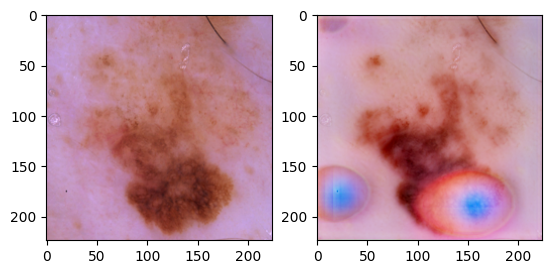

In [25]:
ind = 10
fig, axs = plt.subplots(1, 2)
axs[0].imshow(factuals[ind].permute(1, 2, 0))

axs[1].imshow(cfes[ind].permute(1, 2, 0).detach().cpu())
torch.argmax(baseline_classifier(cfes[ind].unsqueeze(0)), axis=1)